# Семинар 3-4. Математика машинного обучения

**Дисциплина «ИИ и машинное обучение»** · НИУ ВШЭ, Высшая школа бизнеса

Магистратура «Бизнес-аналитика и цифровые решения в финансах»

| Часть | О чём | Итог части |
|---|---|---|
| 1 | Скалярное произведение | как получить одно число из списка характеристик |
| 2 | Матрица на вектор | как сделать то же самое сразу для всех строк таблицы |
| 3 | Матрица на матрицу | как перемножить две таблицы и зачем это нейросети |
| 4 | Вероятность | что означает число, которое выдаёт модель |
| 5 | Производная и градиент | как подкрутить веса, чтобы ошибка уменьшилась |
| 6 | Сборка | находим веса на данных и сверяем с истинными |

**Как работать.** Ячейки с заголовком **Задание** содержат `...` или
`raise NotImplementedError` — их надо заменить своим кодом. Сразу под каждым
заданием стоит ячейка самопроверки: если всё верно, она печатает `✓ верно`,
если нет — подсказывает, где ошибка.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.2, 3.8), "figure.dpi": 110, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, INK, RED, GREY = "#0057b8", "#0d2340", "#c0392b", "#8a9bb0"


def check(ok, hint):
    "Самопроверка задания."
    if not ok:
        raise AssertionError("✗ " + hint)
    print("✓ верно")



# ── учебный архив погоды ───────────────────────────────────────────────────
# Архив синтетический: числа подобраны для наглядности, а не для
# метеорологической точности. Веса W_TRUE заданы нами — в математическом
# ноутбуке они понадобятся, чтобы проверить, что градиентный спуск их нашёл.
# В настоящей задаче их не знает никто.
rng = np.random.default_rng(20260908)
n_days = 365

pressure = np.round(760 + 8 * rng.normal(size=n_days), 1)
humidity = np.round(np.clip(70 + 12 * rng.normal(size=n_days), 25, 100), 1)
clouds = np.round(np.clip(5 + 2.5 * rng.normal(size=n_days), 0, 10), 1)
wind = np.round(np.clip(4 + 2 * rng.normal(size=n_days), 0, 15), 1)

FEATURES = ["Давление", "Влажность", "Облачность", "Ветер"]
RAW = np.column_stack([pressure, humidity, clouds, wind])
Z = (RAW - RAW.mean(axis=0)) / RAW.std(axis=0)
W_TRUE = np.array([-0.9, 1.2, 1.6, 0.35])
B_TRUE = 9.0
rainfall = np.round(B_TRUE + Z @ W_TRUE + 0.6 * rng.normal(size=n_days), 1)

weather = pd.DataFrame(RAW, columns=FEATURES)
weather["Осадки"] = rainfall


print("Архив: %d дней, %d признака" % weather[FEATURES].shape)
weather.head()

---
# Часть 1. Скалярное произведение

## Зачем оно вообще нужно

Собираем рюкзак в поход. Кладём 3 банки консервов по 400 г, 2 бутылки воды
по 500 г, палатку 2500 г и 4 батончика по 60 г. Сколько весит рюкзак?

Вы, не задумываясь, сделаете следующее: **количество** каждого продукта умножаете на его
**стоимость** и складываете. Два списка чисел на входе, одно число на
выходе. Это и есть скалярное произведение.

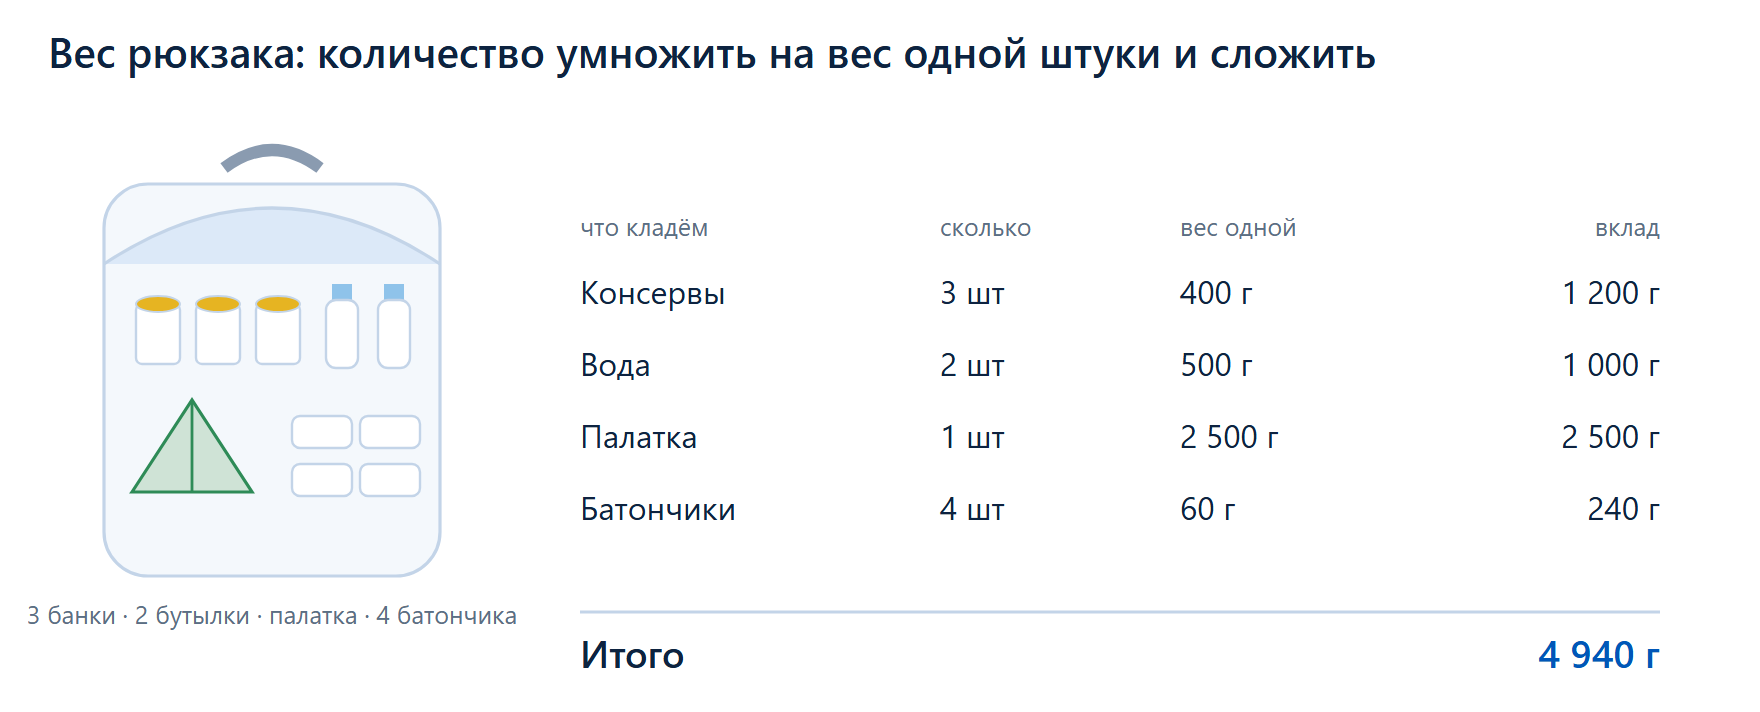

In [ ]:
counts = np.array([3, 2, 1, 4])           # консервы, вода, палатка, батончики
unit_g = np.array([400, 500, 2500, 60])   # вес одной штуки, г

total = 0
for c, u in zip(counts, unit_g):
    total += c * u
print("Через цикл:                  ", total, "г")
print("Через скалярное произведение:", counts @ unit_g, "г")

Формально: для векторов $a$ и $b$ длины $d$

$$a \cdot b = \sum_{i=1}^{d} a_i b_i$$

В numpy это `a @ b` или `np.dot(a, b)`. Обратите внимание: **на входе два
вектора, на выходе одно число.** Векторы обязаны быть одной длины — иначе
непонятно, что на что умножать.

### Задание 1.1
Другой рюкзак: 2 банки консервов (400 г), 3 бутылки воды (500 г), 1 палатка
(2500 г), 6 батончиков (60 г) и 2 газовых баллона (350 г). Посчитайте вес рюкзака.

In [ ]:
counts_2 = np.array([2, 3, 1, 6, 2])
unit_g_2 = np.array([400, 500, 2500, 60, 350])

total_2 = ...  # TODO: перемножьте два вектора скалярно

print("Вес рюкзака:", total_2, "г")
check(total_2 == 5860, "должно получиться 5860 г: 800 + 1500 + 2500 + 360 + 700")

## Ступень вторая: веса не физические, а назначенные

В рюкзаке вес банки написан на банке. Но та же операция работает и там, где
никакого физического веса нет. Ваша итоговая оценка за этот курс:

$$О_{итог} = 0{,}10 \cdot Посещаемость + 0{,}20 \cdot Проверочные +
0{,}25 \cdot Практические + 0{,}15 \cdot Тест + 0{,}30 \cdot Проект$$

Это тот же рюкзак: вектор весов и вектор баллов. Только веса задал не
производитель консервов, а регламент дисциплины.

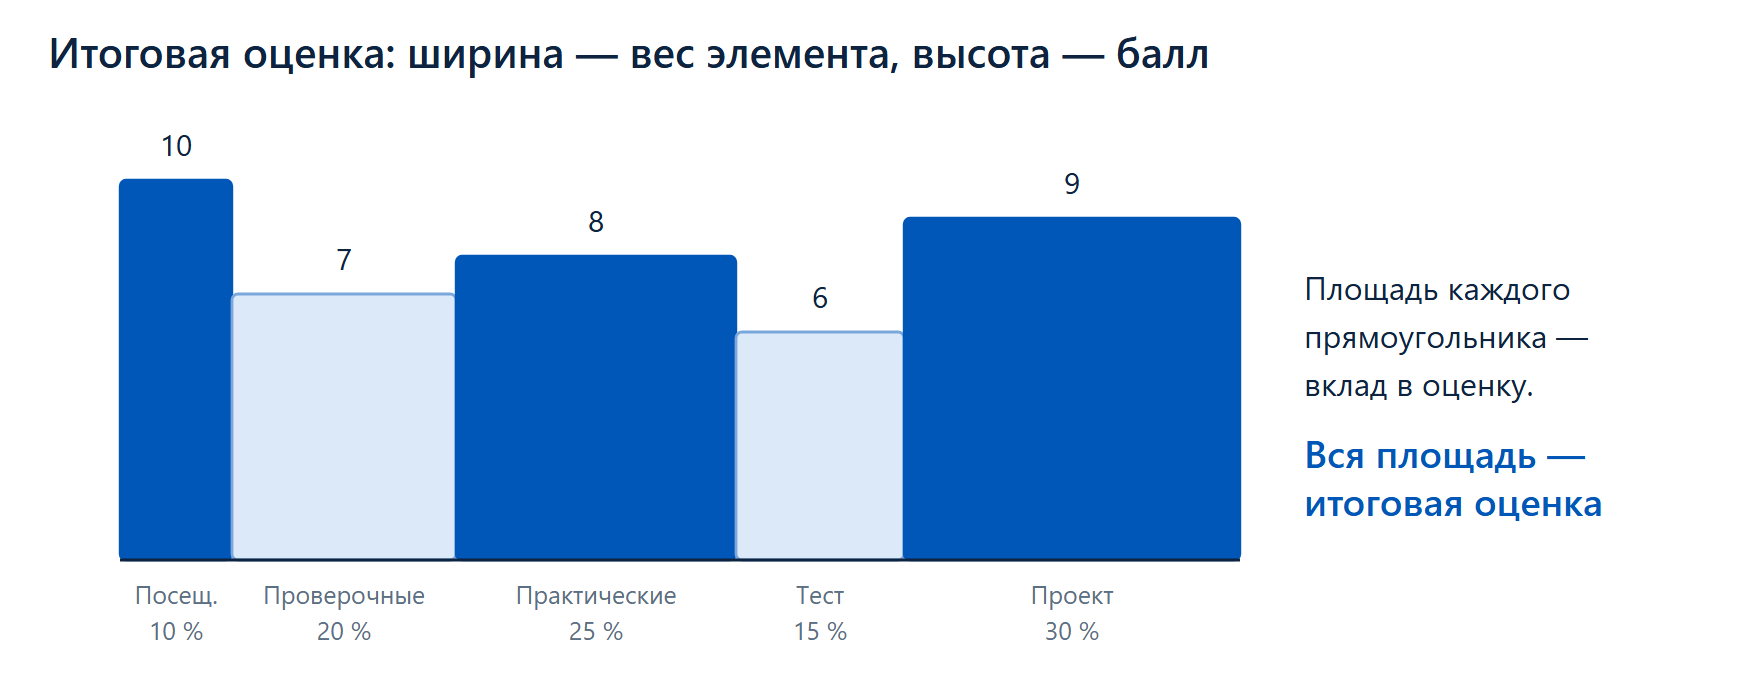

## Ступень третья: веса неизвестны

Теперь главное. Прогноз погоды устроен точно так же: признаки завтрашнего
дня — давление, влажность, облачность, ветер — умножаются на веса и
складываются.

Разница с рюкзаком одна, и она принципиальная:

> **Вес банки консервов написан на банке. "Вес" влажности не написан нигде.**

Его придётся достать из данных. Именно этим занимается машинное обучение. А пока просто возьмём какие-нибудь веса
с потолка и посмотрим, что получается.

In [ ]:
day = weather.iloc[0][FEATURES].to_numpy()
w_guess = np.array([-0.05, 0.03, 0.20, 0.02])   # веса взяты с потолка

print("Признаки дня: ", dict(zip(FEATURES, day)))
print("Балл дождливости:", round(day @ w_guess, 2))

## Второй аспект той же операции: похожесть

Скалярное произведение умеет ещё одну вещь. Возьмём двух зрителей и их оценки
одним и тем же пяти фильмам. Произведение будет большим, когда высокие оценки
стоят у одних и тех же фильмов, — то есть когда вкусы совпадают.

Чтобы длина векторов не мешала (один ставит всем 9 и 10, другой всем 2 и 3),
произведение нормируют на длины. Получается косинус угла:

$$\cos\theta = \frac{a \cdot b}{\|a\| \cdot \|b\|}$$

Знак косинуса читается буквально:

* $> 0$ — направления согласованы, вкусы похожи;
* $= 0$ — векторы **ортогональны**, связи нет. Рост в сантиметрах и любовь к
  кофе: знание одного ничего не говорит о другом;
* $< 0$ — направления противоположны.

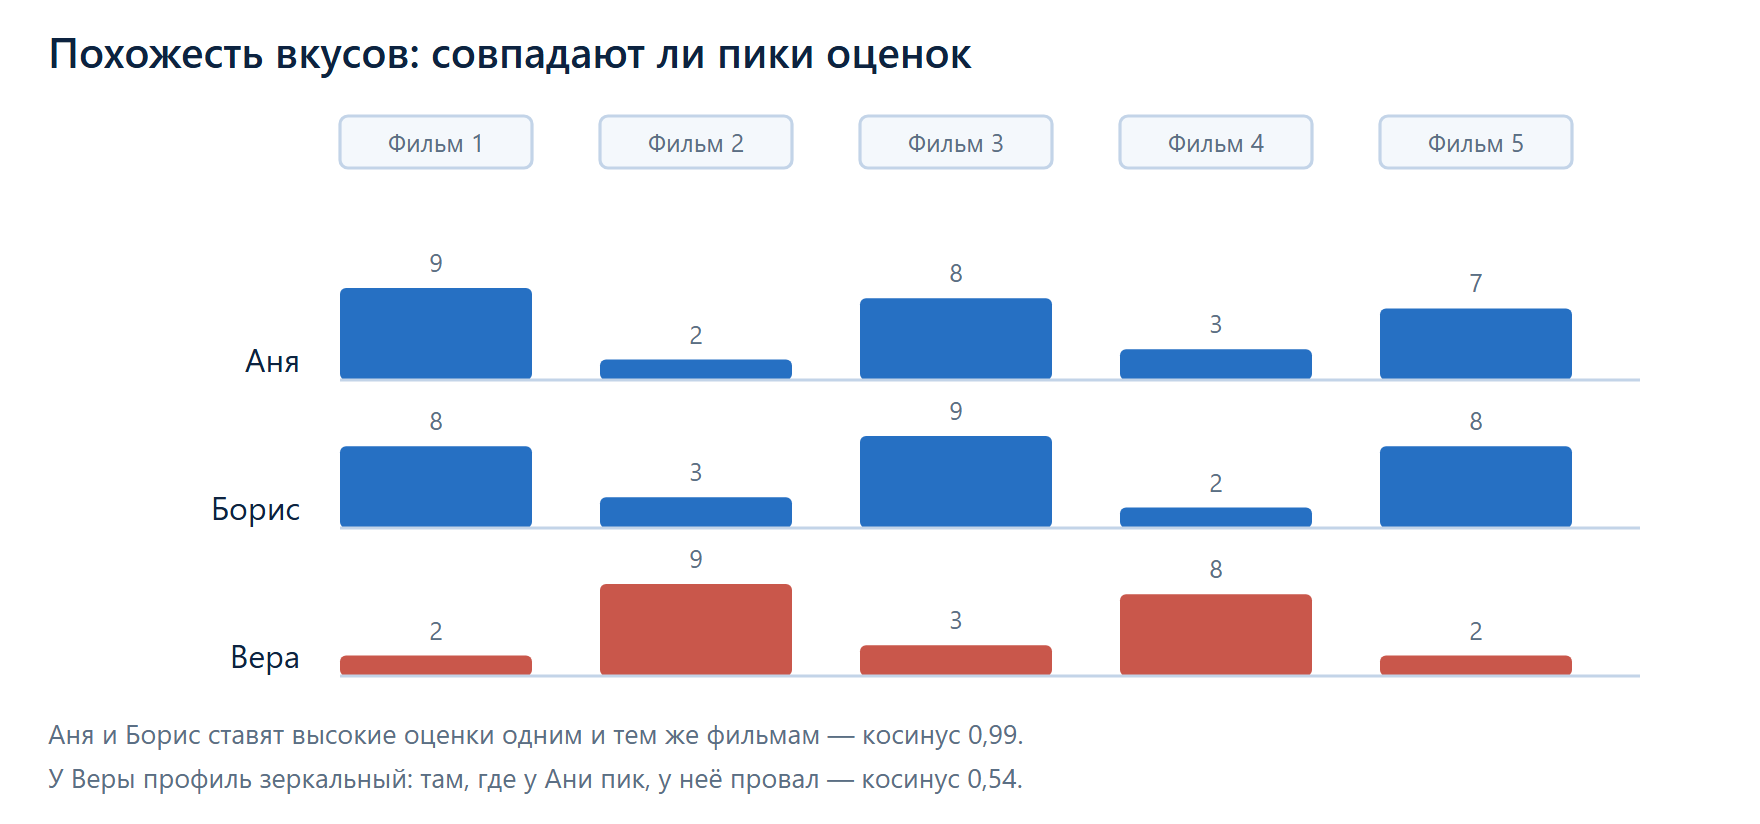

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2))
pairs = [((3, 1), (2.6, 2.2), "вкусы похожи"),
         ((3, 1), (-1, 3), "связи нет"),
         ((3, 1), (-2.6, -1.6), "противоположны")]
for ax, (a, b, label) in zip(axes, pairs):
    a, b = np.array(a), np.array(b)
    cos = a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
    for v, col in ((a, BLUE), (b, RED)):
        ax.annotate("", xy=v, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2))
    ax.set_xlim(-4, 4); ax.set_ylim(-3, 3.6)
    ax.set_aspect("equal"); ax.axhline(0, color=GREY, lw=.8); ax.axvline(0, color=GREY, lw=.8)
    ax.set_title("%s\ncos = %+.2f" % (label, cos), fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### Задание 1.3
Четверо зрителей выставили оценки пяти фильмам. Вычислите косинусную меру
и найдите, кто по вкусам ближе всего к Ане.

In [ ]:
NAMES = ["Аня", "Борис", "Вера", "Глеб"]
ratings = np.array([
    [9, 2, 8, 3, 7],   # Аня
    [8, 3, 9, 2, 8],   # Борис
    [2, 9, 3, 8, 2],   # Вера
    [7, 4, 6, 5, 6],   # Глеб
])


def cosine(a, b):
    "Косинус угла между векторами a и b."
    # TODO: скалярное произведение, делённое на произведение длин
    raise NotImplementedError("замените эту строку своим решением")


for i in range(1, 4):
    print("Аня ↔ %-6s  cos = %.3f" % (NAMES[i], cosine(ratings[0], ratings[i])))

closest = NAMES[1 + int(np.argmax([cosine(ratings[0], ratings[i]) for i in (1, 2, 3)]))]
print("\nБлиже всего к Ане:", closest)

check(abs(cosine(np.array([1, 0]), np.array([0, 1]))) < 1e-9,
      "у перпендикулярных векторов косинус должен быть 0")
check(abs(cosine(np.array([2, 4]), np.array([1, 2])) - 1) < 1e-9,
      "у сонаправленных векторов косинус должен быть 1")
check(closest == "Борис", "проверьте формулу: ближайшим должен оказаться Борис")

---
# Часть 2. Матрица на вектор

## Обобщение на множество "строк"

Предсказание для одного дня считать умеем. Но в архиве 365 дней, а веса при этом
**одни и те же для всех**. Переписывать скалярное произведение 365 раз глупо.

Матрица на вектор — это «посчитать одну и ту же взвешенную сумму сразу для
всех строк таблицы»:

$$(Xw)_i = \sum_{j=1}^{d} X_{ij} w_j = (\text{строка } i) \cdot w$$

То есть **строка $i$ результата — это скалярное произведение строки $i$ таблицы
на вектор весов**. Ничего нового, просто много раз подряд.

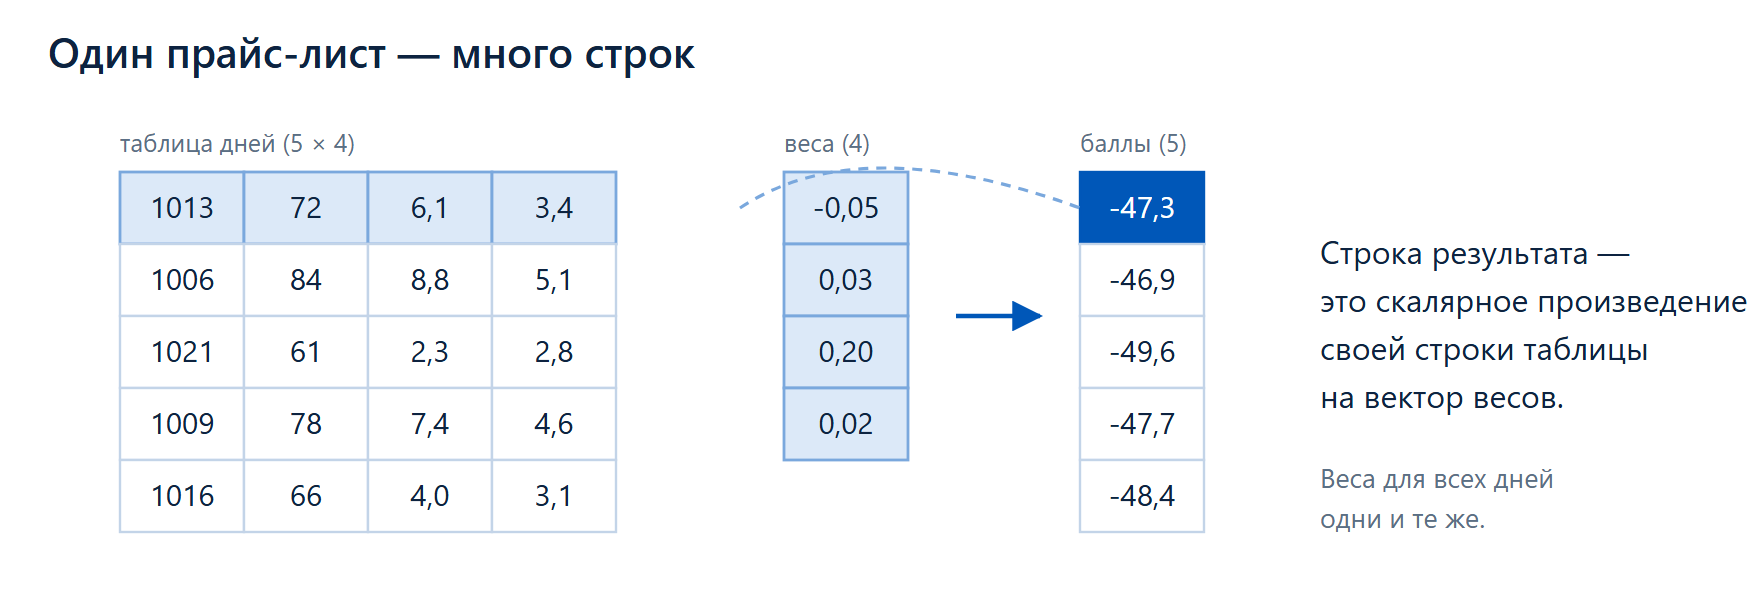

In [ ]:
X_small = weather[FEATURES].to_numpy()[:5]
scores_small = X_small @ w_guess

print("Таблица 5 дней (форма %s):" % (X_small.shape,))
print(X_small)
print("\nБаллы дождливости всех пяти дней:", scores_small)

### Задание 2.1
Посчитайте баллы дождливости для всего архива и найдите день с наибольшим баллом.

In [ ]:
X_all = weather[FEATURES].to_numpy()

scores_all = ...  # TODO: умножьте матрицу признаков на вектор весов
best_day = ...  # TODO: номер дня с наибольшим баллом (np.argmax)

print("Форма результата:", scores_all.shape)
print("Самый «дождливый» по баллу день — номер %d, балл %.2f" % (best_day, scores_all[best_day]))
print("Реальные осадки в этот день:", weather["Осадки"][best_day], "мм")

check(scores_all.shape == (365,), "на выходе должен получиться вектор из 365 чисел, а не матрица")
check(abs(scores_all[7] - X_all[7] @ w_guess) < 1e-9, "строка 7 результата не совпала со скалярным произведением строки 7")
check(scores_all[best_day] == scores_all.max(), "best_day должен указывать на максимум")

## Тот же приём с другой стороны: закупка продуктов

В столовой три блюда, у каждого свой расход продуктов на порцию. Известно,
сколько порций каждого блюда готовим сегодня. Сколько всего закупить?

Здесь хорошо видно, **почему размерности обязаны совпадать**: складывать можно
только по общему списку ингредиентов. Если в рецепте четыре продукта, а в
списке порций три блюда — умножать надо так, чтобы «схлопнулись» именно блюда.

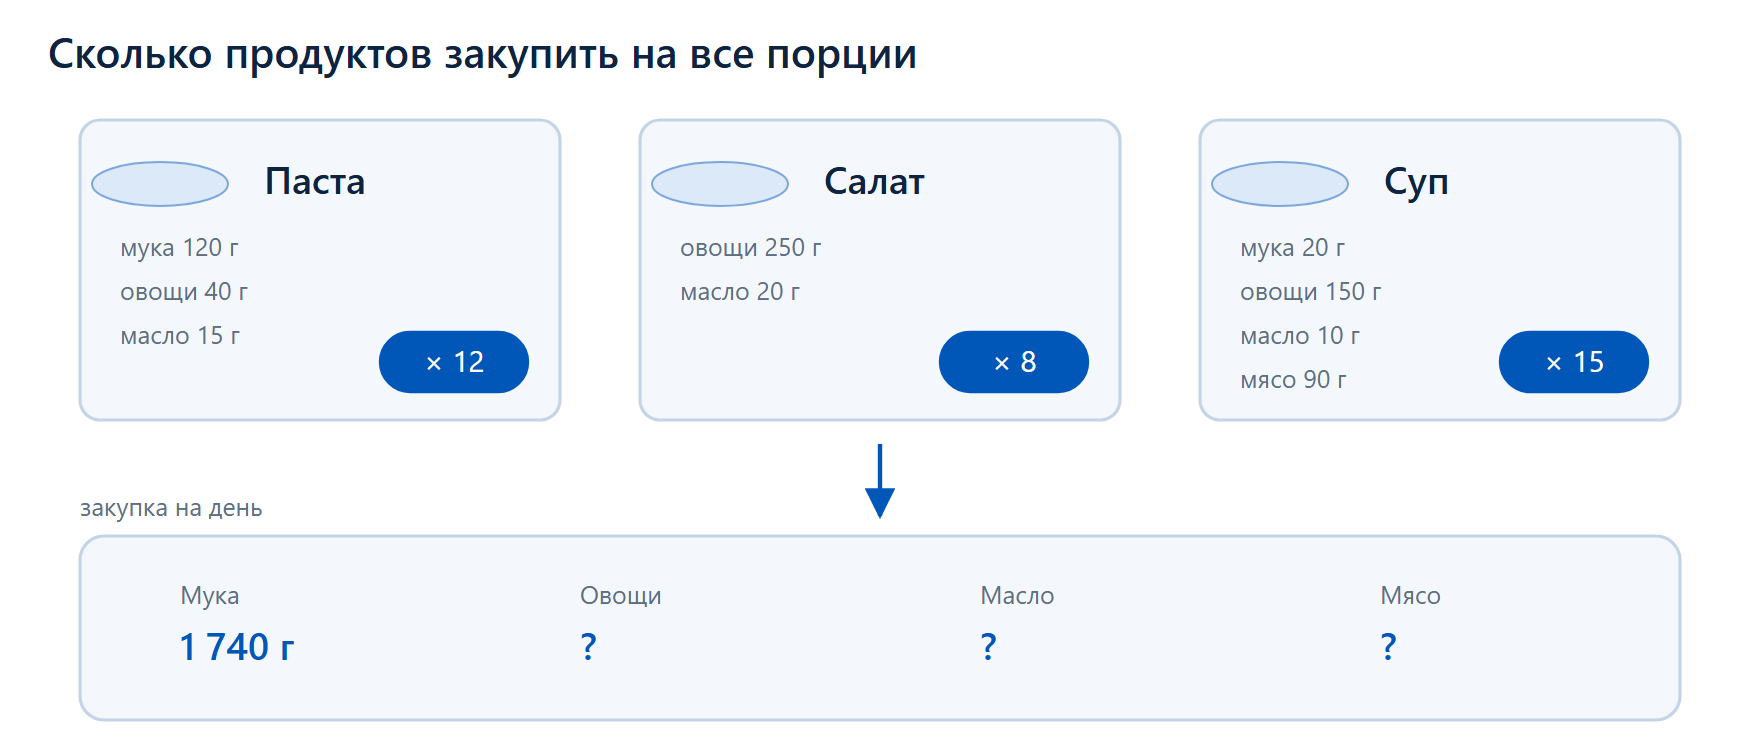

### Задание 2.2
Посчитайте, сколько граммов каждого ингредиента нужно закупить.
Подсказка: понадобится транспонирование `.T`, чтобы размерности сошлись.

In [ ]:
DISHES = ["Паста", "Салат", "Суп"]
INGREDIENTS = ["Мука", "Овощи", "Масло", "Мясо"]
recipe = np.array([          # граммы на одну порцию
    [120,  40, 15,  0],      # паста
    [  0, 250, 20,  0],      # салат
    [ 20, 150, 10, 90],      # суп
])
portions = np.array([12, 8, 15])   # сколько порций готовим

shopping = ...  # TODO: транспонируйте recipe и умножьте на portions

for name, grams in zip(INGREDIENTS, shopping):
    print("%-7s %6.0f г" % (name, grams))

check(shopping.shape == (4,), "на выходе должно быть 4 числа — по одному на ингредиент")
check(np.allclose(shopping, [1740, 4730, 490, 1350]),
      "проверьте порядок множителей: нужно свернуть блюда, а не ингредиенты")

---
# Часть 3. Матрица на матрицу

## Зачем: таблица умножается на таблицу

Продолжаем говорить о 🍝🥗🍲. Есть таблица составов: **блюдо × ингредиент**, в граммах.
И есть справочник питательности: **ингредиент × нутриент** — белки, жиры,
углеводы, калории в одном грамме продукта.

Перемножив их, получаем таблицу **блюдо × нутриент**: сколько в каждом блюде
каждого нутриента. Элемент $(i, j)$ результата — скалярное произведение состава
$i$-го блюда на колонку $j$-го нутриента:

$$(AB)_{ij} = \sum_{k} A_{ik} B_{kj}$$

Отсюда сразу два правила, которые больше не придётся запоминать:

* **размерности:** $(n \times d) \cdot (d \times k) = (n \times k)$. Общий
  размер $d$ — это список ингредиентов, по нему суммируем;
* **порядок важен:** $AB \neq BA$. Умножить справочник питательности на состав
  блюд нельзя — размеры не сойдутся, да и смысла в этом нет.

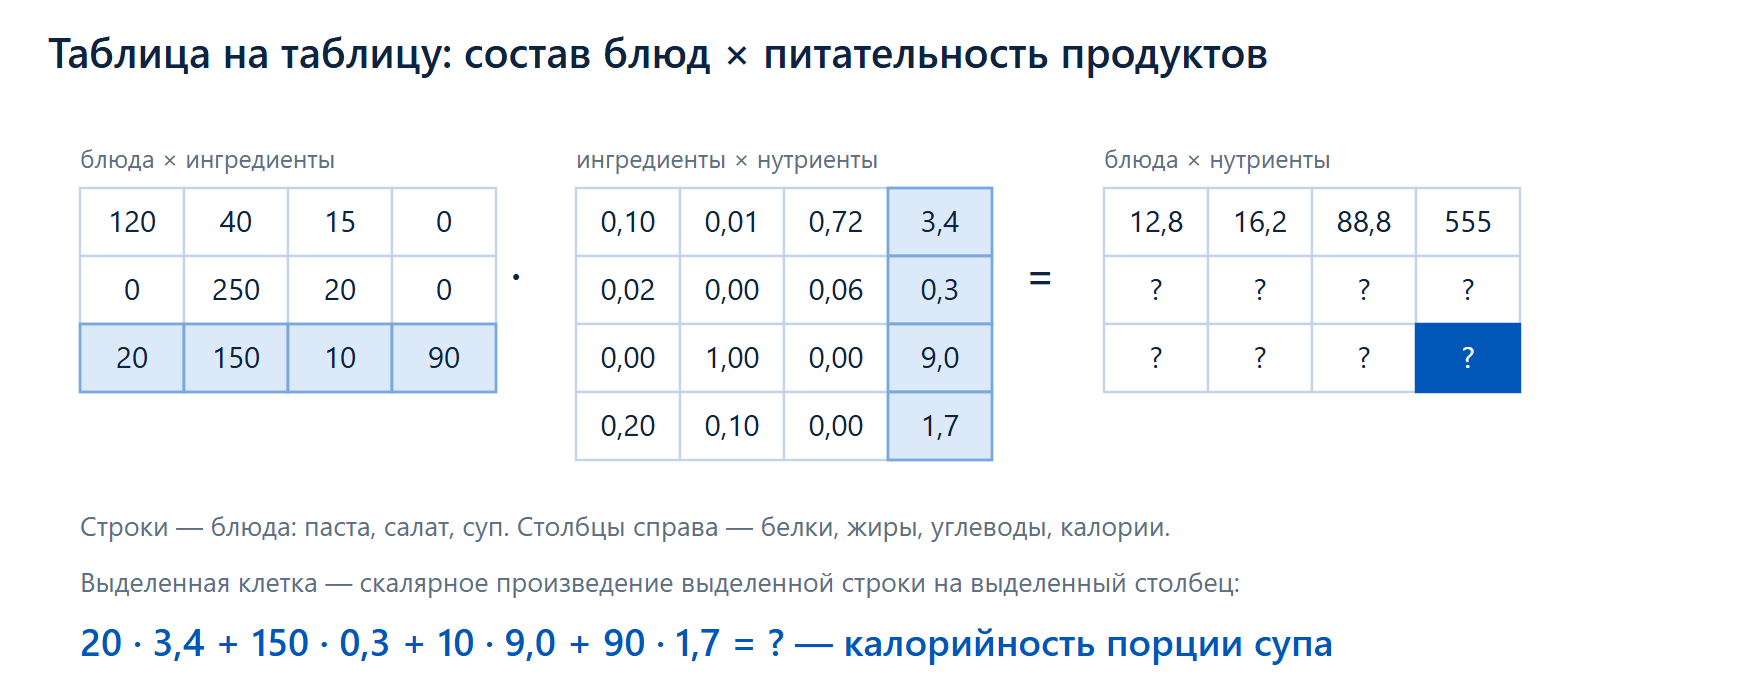

### Задание 3.1
Посчитайте таблицу «блюдо × нутриент» и найдите самое диетическое блюдо.

In [ ]:
NUTRIENTS = ["Белки", "Жиры", "Углеводы", "Калории"]
nutrition = np.array([      # на 1 грамм продукта
    [0.10, 0.01, 0.72, 3.4],   # мука
    [0.02, 0.00, 0.06, 0.3],   # овощи
    [0.00, 1.00, 0.00, 9.0],   # масло
    [0.20, 0.10, 0.00, 1.7],   # мясо
])

dish_nutrition = ...  # TODO: перемножьте матрицы recipe и nutrition
idx_diet_dish = ...  # TODO: перемножьте матрицы recipe и nutrition

df = pd.DataFrame(dish_nutrition, index=DISHES, columns=NUTRIENTS).round(1)
print(df)

check(dish_nutrition.shape == (3, 4), "форма результата должна быть 3 × 4: три блюда, четыре нутриента")
check(abs(dish_nutrition[0, 3] - 555.0) < 1e-6, "в пасте должно получиться 555 ккал")
check(idx_diet_dish == 1, "Индекс должен быть равен `1`")

**Связка с курсом.** Слой нейросети — это матрица весов, а набор объектов —
матрица данных. Обучение сети сводится к таким перемножениям, повторённым
миллионы раз. Поэтому машинное обучение и переехало на видеокарты: они умеют
перемножать матрицы очень быстро.

---
# Часть 4. Вероятность

## Вероятность события — это **доля** случаев, когда это событие происходило за какой-то период времени

Пример: доля дождливых дней 20 % означает, что в таблице
из 365 строк примерно 73 строки помечены дождём.

### Задание 4.1
Будем считать сильным дождём осадки больше 11 мм. Посчитайте долю таких дней.

In [ ]:
HEAVY = 11.0

share = ...  # TODO: доля дней, где осадки больше HEAVY

print("Доля дней с сильным дождём: %.1f %%" % (100 * share))
check(0.10 < share < 0.30, "доля должна получиться примерно пятая часть года")

## Условная вероятность — доля внутри подгруппы

Теперь сузим группу. Возьмём не все дни подряд, а только те, где облачность
*выше* средней **и** давление *ниже* среднего, и пересчитаем ту же долю.

Запись $P(\text{дождь} \mid \text{пасмурно и низкое давление})$ читается
буквально: «доля дождливых **среди** дней с такими признаками».

### Задание 4.2

In [ ]:
mask = ((weather["Облачность"] > weather["Облачность"].mean())
        & (weather["Давление"] < weather["Давление"].mean()))

cond_share = ...  # TODO: доля сильных дождей среди отобранных дней

print("Дней в подгруппе: %d из %d" % (mask.sum(), len(weather)))
print("Без условия:  %.1f %%" % (100 * share))
print("С условием:   %.1f %%" % (100 * cond_share))
check(cond_share > share + 0.15, "условная доля должна оказаться заметно выше безусловной")

> **Главная мысль.** Модель классификации смотрит на признаки объекта и отвечает: «насколько похож данный объект на другие?». То есть оценивает
> $P(y = 1 \mid \text{признаки})$. Всё остальное в курсе — способы
> оценивать эту вероятность точнее.

## Теорема Байеса без формулы

**Задача.** Заболевание встречается у 1 % людей.
Тест обнаруживает болезнь у больного в 95 % случаев (чувствительность) и правильно
"не реагирует" на здорового в 90 % случаев (специфичность).

**Ваш тест положительный. Какова вероятность, что вы больны?**

Прежде чем считать — назовите ответ вслух. Теперь посчитаем не формулой, а
частотами: возьмём 10 000 человек и разложим их по четырём клеткам.

### Задание 4.3
Заполните клетки таблицы и посчитайте долю действительно больных среди всех,
у кого тест дал положительный результат.

In [ ]:
N = 10000
prevalence, sensitivity, specificity = 0.01, 0.95, 0.90

sick = ...  # TODO: сколько человек из N действительно больны
healthy = ...  # TODO: сколько человек здоровы
true_pos = ...  # TODO: у скольких больных тест сработал
false_pos = ...  # TODO: у скольких здоровых тест сработал ошибочно

p_sick_if_positive = ...  # TODO: доля больных среди всех положительных

print("Больных:                  %6.0f" % sick)
print("Здоровых:                 %6.0f" % healthy)
print("Верных срабатываний:      %6.0f" % true_pos)
print("Ложных срабатываний:      %6.0f" % false_pos)
print("Всего положительных:      %6.0f" % (true_pos + false_pos))
print("\nP(болен | тест положительный) = %.1f %%" % (100 * p_sick_if_positive))

check(abs(p_sick_if_positive - 95 / 1085) < 1e-9,
      "должно получиться около 8,8 %: 95 верных срабатываний против 990 ложных")

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.barh(["Положительный тест"], [true_pos], color=BLUE, label="действительно больны (%.0f)" % true_pos)
ax.barh(["Положительный тест"], [false_pos], left=[true_pos], color=GREY,
        label="ложная тревога (%.0f)" % false_pos)
ax.set_xlabel("человек из 10 000")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", alpha=0)
ax.set_title("Почти все положительные тесты — у здоровых", fontsize=11)
plt.tight_layout(); plt.show()

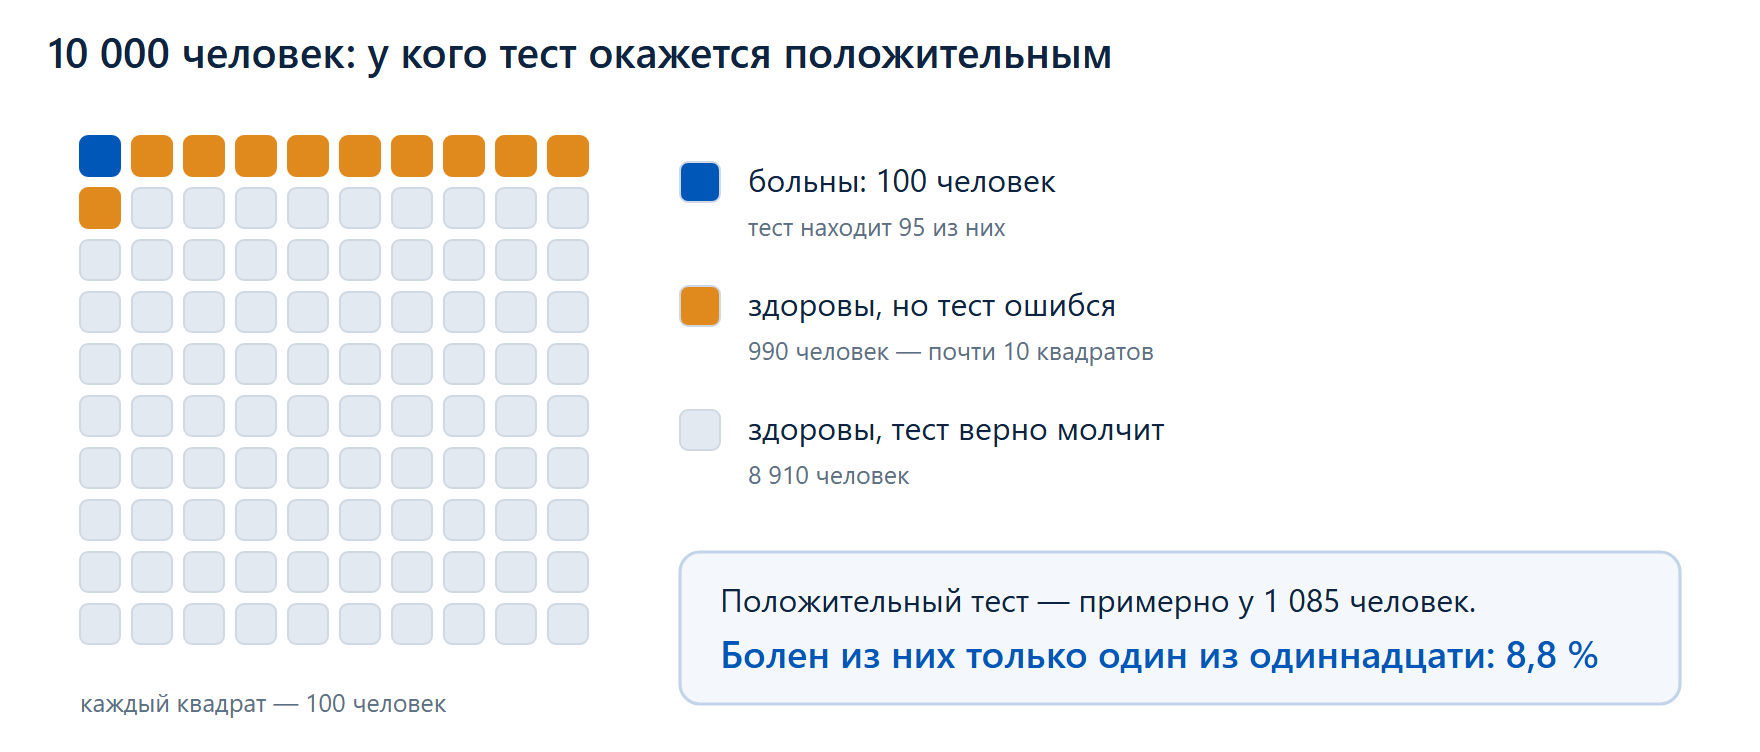

Причина не в качестве теста, а в **редкости события**: здоровых так много, что
даже 10 % ошибок на них дают больше срабатываний, чем все больные вместе взятые.
Ровно с этим мы столкивались во второй лекции, когда говорили про дисбаланс
классов.

Формула Байеса — это та же таблица, записанная компактно:

$$P(A \mid B) = \frac{P(B \mid A) \, P(A)}{P(B)}$$

**Независимость** событий: события независимы, если наступление
одного не влияет на наступление другого. Монета и погода независимы. А вот два дня
подряд — нет, и три замера температуры у одного пациента — тоже нет. 

*Признаки, порождённые одним источником, нельзя считать
независимыми наблюдениями.*

## Среднее и разброс: два маршрута до аэропорта

Два маршрута, оба в среднем занимают около 40 минут. Первый — стабильные
40 ± 5. Второй обычно 33 минуты, но раз в семь поездок попадает в пробку и
занимает полтора часа.

Средние одинаковые. Что выберете перед вылетом?

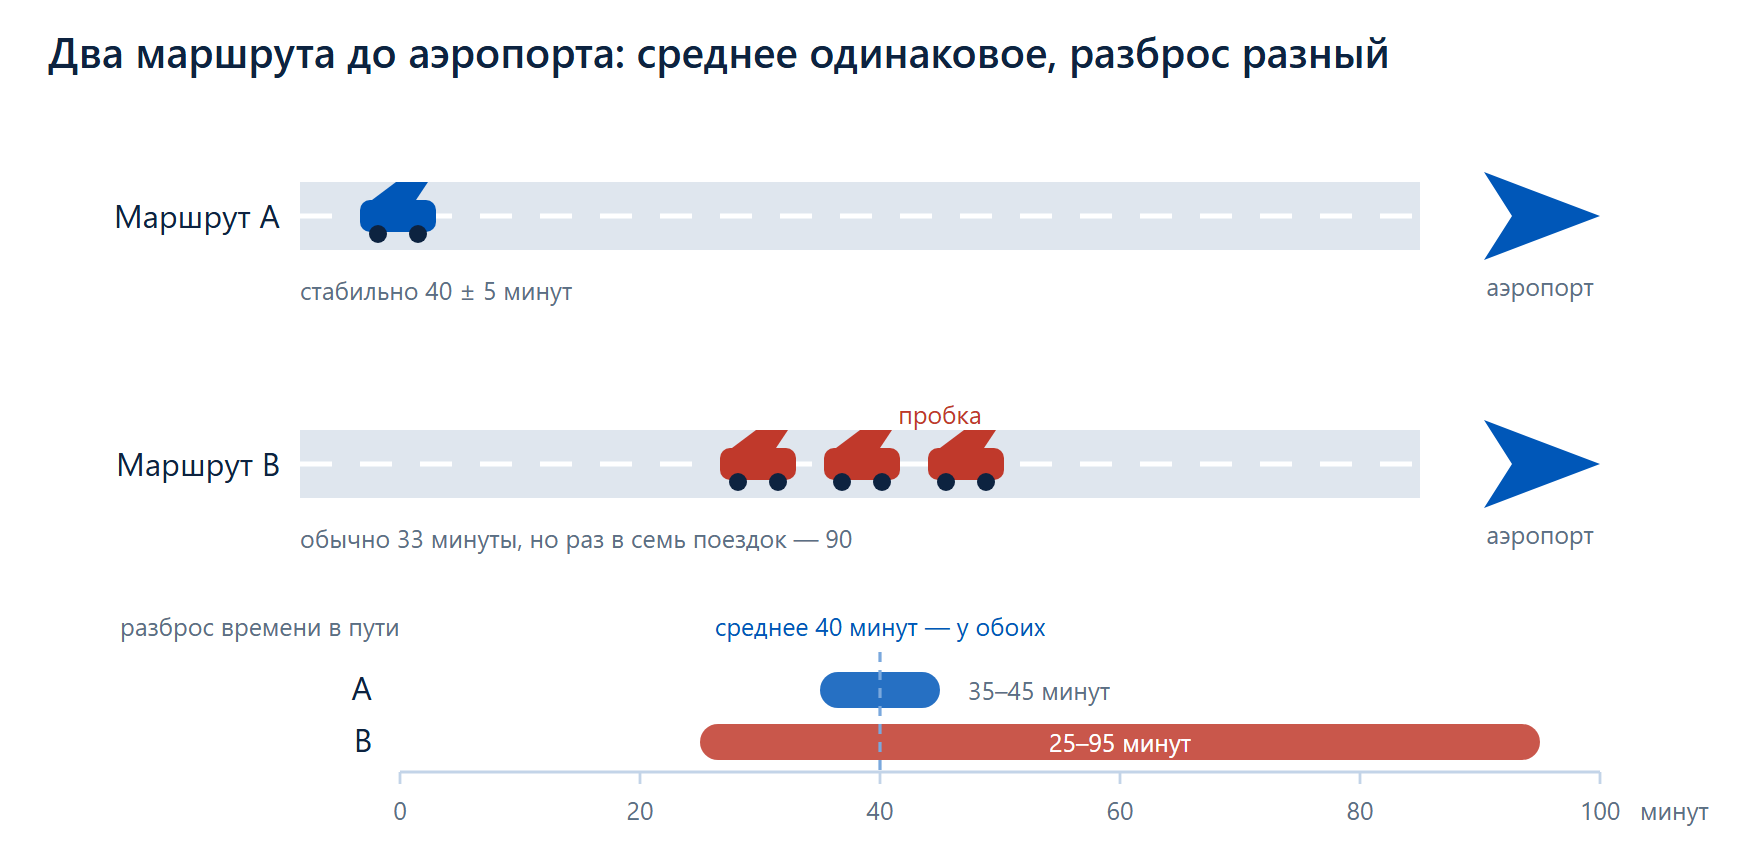

### Задание 4.4
Посчитайте среднее и стандартное отклонение для обоих маршрутов.

In [ ]:
rng2 = np.random.default_rng(7)
route_a = rng2.normal(40, 5, size=500)
route_b = np.where(rng2.random(500) < 0.85,
                   rng2.normal(33, 4, size=500),
                   rng2.normal(80, 10, size=500))

mean_a, std_a = ...  # TODO: среднее и стандартное отклонение маршрута A
mean_b, std_b = ...  # TODO: среднее и стандартное отклонение маршрута B

print("Маршрут A: среднее %.1f мин, разброс %.1f мин" % (mean_a, std_a))
print("Маршрут B: среднее %.1f мин, разброс %.1f мин" % (mean_b, std_b))

check(abs(mean_a - mean_b) < 2.0, "средние должны получиться почти одинаковыми")
check(std_b > 2 * std_a, "разброс второго маршрута должен быть заметно больше")

In [ ]:
fig, ax = plt.subplots()
bins = np.linspace(15, 110, 40)
ax.hist(route_a, bins=bins, alpha=.75, color=BLUE, label="маршрут A")
ax.hist(route_b, bins=bins, alpha=.75, color=RED, label="маршрут B")
ax.axvline(mean_a, color=INK, ls="--", lw=1.2)
ax.axvline(mean_b, color=INK, ls="--", lw=1.2)
ax.set_xlabel("время в пути, мин"); ax.set_ylabel("число поездок")
ax.set_title("Одинаковое среднее, разный разброс", fontsize=11)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---
# Часть 5. Производная и градиентный спуск

## Производная — это скорость изменения

Производная отвечает на бытовой вопрос: **на сколько
изменится результат, если чуть-чуть подкрутить ручку.**

Главная метафора этой части — **настройка душа**. Есть два крана, цель —
комфортная температура, ошибка — отклонение от неё. Вы поворачиваете кран
на чуть-чуть, чувствуете, куда пошла температура, и поворачиваете дальше.
Это и есть градиентный спуск, вы им пользуетесь каждое утро.

На картинке явно видно:

* **знак производной** — в какую сторону крутить;
* **градиент** — два крана вместо одного: список чувствительностей по каждому;
* **длина шага** — крутить медленно значит мыться в холодной ещё долго, крутить
  быстро значит ошпариться.

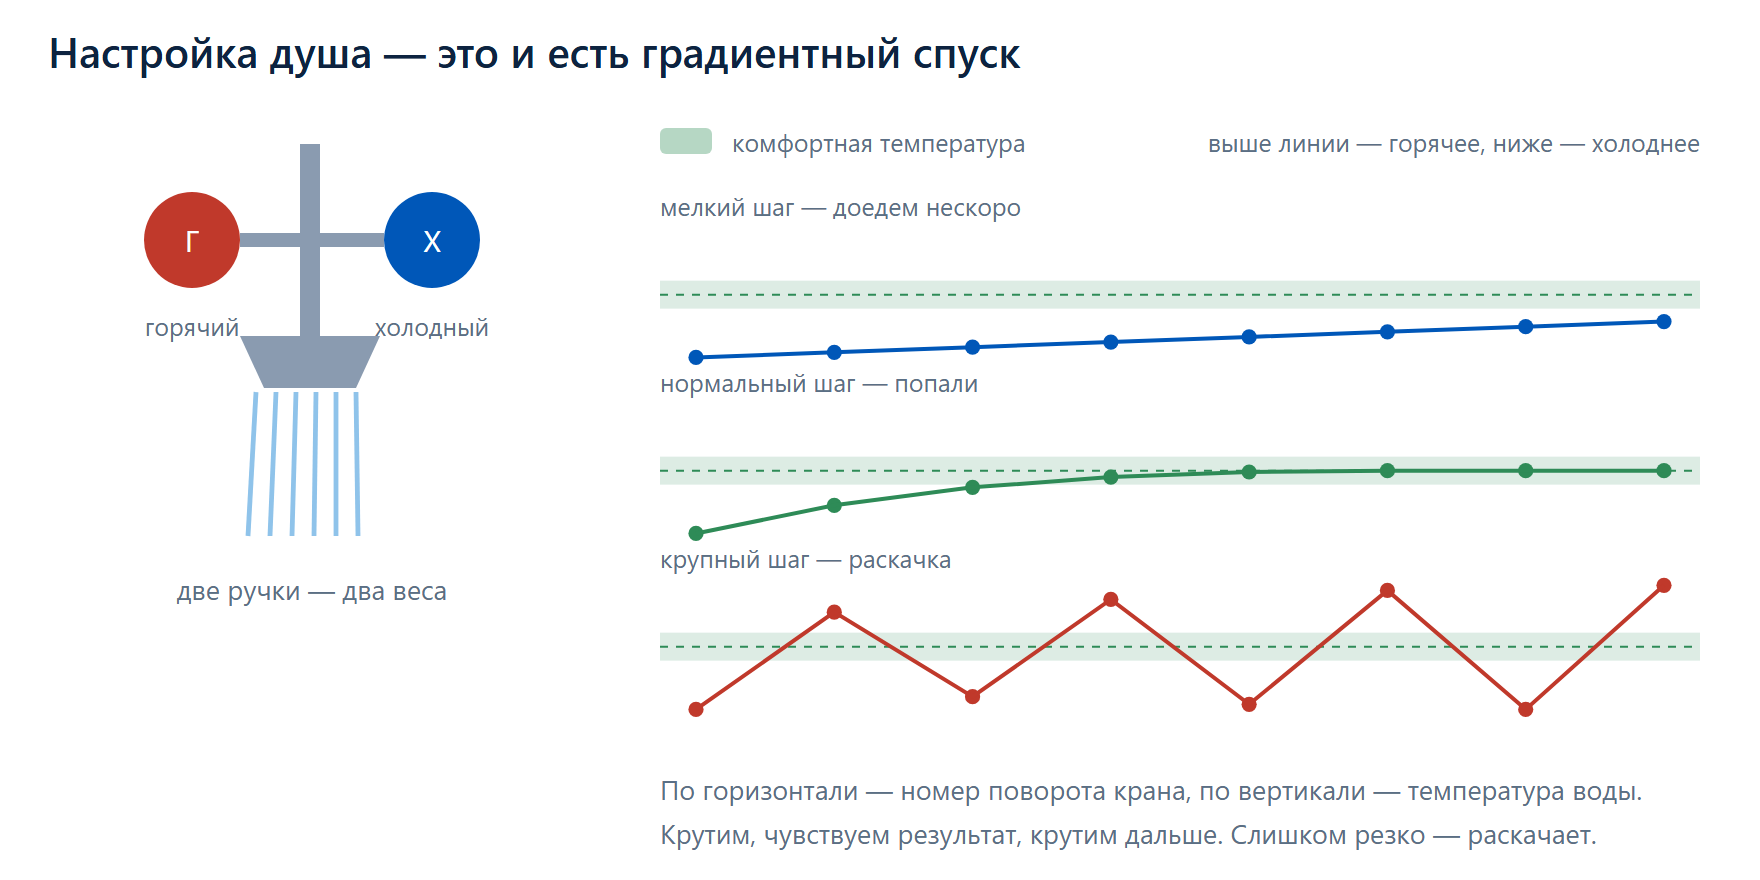

In [ ]:
def loss_1d(w):
    "Ошибка при одной ручке."
    return (w - 3.0) ** 2 + 1.0


h = 1e-5
for w0 in (0.0, 3.0, 5.0):
    d = (loss_1d(w0 + h) - loss_1d(w0 - h)) / (2 * h)
    side = "вправо" if d < 0 else ("влево" if d > 0 else "не надо, комфортная температура")
    print("w = %.1f:  ошибка = %5.2f,  производная = %+6.2f  ->  крутить %s"
          % (w0, loss_1d(w0), d, side))

Правило градиентного спуска: **шагаем против знака производной.**

$$w \leftarrow w - \eta \cdot \frac{dL}{dw}$$

Здесь $\eta$ — длина шага (learning rate), то самое «насколько резко крутить».

### Задание 5.1
Реализуйте производную и один шаг градиентного спуска, а затем посмотрите, что бывает при
разной длине шага.

In [ ]:
def grad_1d(w):
    "Производная (w - 3)^2 + 1 по w."
    # TODO: вычислите производную
    raise NotImplementedError("замените эту строку своим решением")


def descend(w0, eta, steps=25):
    w, path = w0, [w0]
    for _ in range(steps):
        w = ...  # TODO: сделайте шаг против направления производной с шагом eta
        path.append(w)
    return np.array(path)


slow, good, wild = descend(0.0, 0.05), descend(0.0, 0.4), descend(0.0, 1.05)
print("шаг 0,05 — пришли в %.3f" % slow[-1])
print("шаг 0,40 — пришли в %.3f" % good[-1])
print("шаг 1,05 — пришли в %.3f" % wild[-1])

check(abs(good[-1] - 3.0) < 1e-3, "при шаге 0,4 спуск должен сойтись в точку 3")
check(abs(wild[-1] - 3.0) > 10, "при шаге 1,05 спуск обязан разойтись — проверьте знак в шаге")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), sharey=True)
grid = np.linspace(-4, 10, 200)
for ax, (path, title) in zip(axes, [(slow, "шаг 0,05 — ползём"),
                                    (good, "шаг 0,40 — в самый раз"),
                                    (wild, "шаг 1,05 — раскачка")]):
    ax.plot(grid, loss_1d(grid), color=GREY, lw=1.4)
    p = np.clip(path, -4, 10)
    ax.plot(p, loss_1d(p), "o-", color=BLUE, ms=4, lw=1.1)
    ax.set_title(title, fontsize=10); ax.set_xlabel("w")
axes[0].set_ylabel("ошибка"); axes[0].set_ylim(0, 60)
plt.tight_layout(); plt.show()

## Градиент: ручек несколько

Когда ручек две, чувствительность считают по каждой отдельно. Список этих
чувствительностей и называется **градиентом**:

$$\nabla L = \left( \frac{\partial L}{\partial w_0},\ \frac{\partial L}{\partial w_1} \right)$$

Возьмём настоящую задачу: предсказываем осадки по одной облачности,
$\hat{y} = w_0 + w_1 x$. Ошибка — средний квадрат отклонения:

$$L(w_0, w_1) = \frac{1}{n}\sum_{i=1}^{n} \left(y_i - w_0 - w_1 x_i\right)^2$$

### Задание 5.2
Реализуйте градиент и спуститесь по нему за 60 шагов.

In [ ]:
x_one = Z[:, 2]          # стандартизованная облачность
y_one = rainfall


def mse(w0, w1):
    return float(np.mean((y_one - w0 - w1 * x_one) ** 2))


def grad_mse(w0, w1):
    "Частные производные MSE по w0 и по w1."
    resid = y_one - w0 - w1 * x_one
    # TODO: продифференцируйте средний квадрат по каждому весу
    raise NotImplementedError("замените эту строку своим решением")


w0, w1, eta = 0.0, 0.0, 0.3
track = [(w0, w1)]
for _ in range(60):
    g0, g1 = grad_mse(w0, w1)
    w0, w1 = w0 - eta * g0, w1 - eta * g1
    track.append((w0, w1))
track = np.array(track)

print("Найдено: w0 = %.2f, w1 = %.2f, ошибка = %.3f" % (w0, w1, mse(w0, w1)))
check(mse(w0, w1) < mse(0, 0), "ошибка обязана уменьшиться по сравнению со стартом")
check(1.0 < w1 < 2.2, "наклон должен получиться примерно 1,6 — столько осадков добавляет облачность")

In [ ]:
g0v, g1v = np.meshgrid(np.linspace(-1, 11, 120), np.linspace(-1.5, 3.0, 120))
surface = np.array([[mse(a, b) for a, b in zip(r0, r1)] for r0, r1 in zip(g0v, g1v)])

fig, ax = plt.subplots(figsize=(6.6, 4.0))
cs = ax.contour(g0v, g1v, surface, levels=25, colors=GREY, linewidths=.7)
ax.plot(track[:, 0], track[:, 1], "o-", color=BLUE, ms=3.5, lw=1.2, label="путь спуска")
ax.plot(track[0, 0], track[0, 1], "o", color=RED, ms=7, label="старт")
ax.set_xlabel("$w_0$ — сдвиг"); ax.set_ylabel("$w_1$ — наклон")
ax.set_title("Спуск по ландшафту ошибки", fontsize=11)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Цепное правило (Chain rule): производные перемножаются

Педаль газа влияет на обороты двигателя, обороты — на скорость, скорость — на
расход топлива. Как педаль влияет на расход? Перемножить чувствительности:

$$\frac{d\,\text{расход}}{d\,\text{педаль}} =
\frac{d\,\text{расход}}{d\,\text{скорость}} \cdot
\frac{d\,\text{скорость}}{d\,\text{обороты}} \cdot
\frac{d\,\text{обороты}}{d\,\text{педаль}}$$

Это цепное правило, и это же — обратное распространение ошибки в нейросети. Сеть тем и отличается, что таких звеньев в ней тысячи.

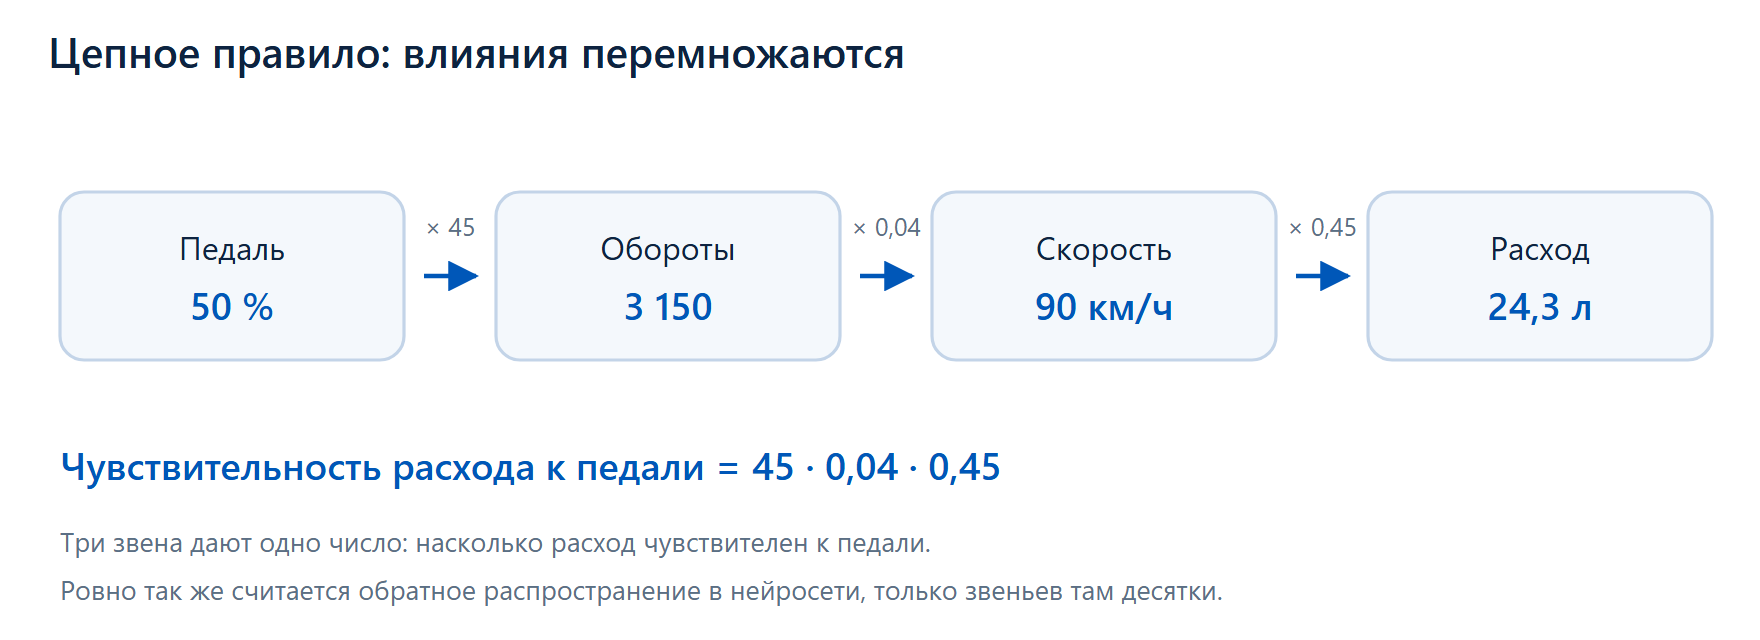

### Задание 5.3
Посчитайте производную по цепному правилу и сверьте с численной.

In [ ]:
def rpm(p):     return 900 + 45 * p          # обороты от положения педали, %
def speed(r):   return 0.04 * (r - 900)      # скорость от оборотов, км/ч
def fuel(v):    return 4 + 0.0025 * v ** 2   # расход от скорости, л/100 км


def dfuel_dpedal(p):
    "Чувствительность расхода к педали в точке p."
    v = speed(rpm(p))
    # TODO: перемножьте три производные
    raise NotImplementedError("замените эту строку своим решением")


p0, h = 50.0, 1e-5
numeric = (fuel(speed(rpm(p0 + h))) - fuel(speed(rpm(p0 - h)))) / (2 * h)

print("По цепному правилу: %.4f" % dfuel_dpedal(p0))
print("Численно:           %.4f" % numeric)
check(abs(dfuel_dpedal(p0) - numeric) < 1e-4,
      "числа должны совпасть: цепное правило — это не приближение, а точная формула")

## Выпуклость: одна яма или много ям

Последнее понятие на сегодня. Ландшафт ошибки бывает двух видов.

* **Одна яма (выпуклый случай).** Гладкая чаша: откуда ни начни спуск, придёшь
  в одно и то же место. Так устроены линейная и логистическая регрессия —
  результат не зависит от того, с чего начали.
* **Много ям (невыпуклый случай).** Горный рельеф с оврагами: куда придёшь,
  зависит от точки старта. Так устроены нейросети. Поэтому их результат
  зависит от начальной инициализации весов, а обучение приходится повторять.

---
# Часть 6*. Сборка: находим оптимальные веса

Всё готово. Возвращаемся к вопросу из первой части: вес банки консервов
написан на банке, а вес влажности не написан нигде. Сейчас мы его достанем.

Схема ровно та же, что в задании 5.2, только ручек теперь четыре:

1. взять текущие веса и посчитать прогноз $\hat{y} = Xw + b$;
2. посмотреть на ошибку $y - \hat{y}$;
3. посчитать градиент — насколько ошибка чувствительна к каждому весу;
4. шагнуть против градиента;
5. повторить.

**Важная деталь перед стартом.** Давление измеряется в районе 760, а
облачность — в баллах от 0 до 10. Если оставить как есть, шаг, разумный для
облачности, окажется чудовищным для давления, и спуск разойдётся. Поэтому
признаки сначала приводят к общему масштабу — вычитают среднее и делят на
стандартное отклонение. В лекции 2 это отдельно обсуждалось.

### Задание 6.1

In [ ]:
y = rainfall

X = ...  # TODO: стандартизуйте признаки: вычесть среднее, поделить на std

w = np.zeros(4)
b = 0.0
eta = 0.1
history = []

for step in range(300):
    resid = y - (X @ w + b)
    history.append(float(np.mean(resid ** 2)))
    grad_w = ...  # TODO: градиент MSE по вектору весов
    grad_b = ...  # TODO: градиент MSE по сдвигу
    w = w - eta * grad_w
    b = b - eta * grad_b

print("Ошибка в начале: %.2f   в конце: %.3f\n" % (history[0], history[-1]))
print("%-12s %8s %8s" % ("Признак", "нашли", "истина"))
for name, found, true in zip(FEATURES, w, W_TRUE):
    print("%-12s %8.2f %8.2f" % (name, found, true))
print("%-12s %8.2f %8.2f" % ("Сдвиг", b, B_TRUE))

check(X.shape == (365, 4), "X должен остаться матрицей 365 × 4")
check(abs(X.mean()) < 1e-8, "после стандартизации среднее каждого признака должно стать нулём")
check(np.allclose(w, W_TRUE, atol=0.15), "найденные веса должны совпасть с истинными — проверьте градиент")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4))
axes[0].plot(history, color=BLUE, lw=1.6)
axes[0].set_xlabel("шаг спуска"); axes[0].set_ylabel("средний квадрат ошибки")
axes[0].set_title("Ошибка падает с каждым шагом", fontsize=11)

pos = np.arange(len(FEATURES))
axes[1].bar(pos - 0.2, W_TRUE, width=0.4, color=GREY, label="истинные веса")
axes[1].bar(pos + 0.2, w, width=0.4, color=BLUE, label="найденные спуском")
axes[1].set_xticks(pos); axes[1].set_xticklabels(FEATURES, fontsize=9)
axes[1].axhline(0, color=INK, lw=.8)
axes[1].set_title("Веса, которых никто не писал на ценнике", fontsize=11)
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---
# Итоги

Мы прошли путь от рюкзака до обученной модели, и вся математика появлялась
только тогда, когда без неё было не обойтись.

| Что | Зачем понадобилось |
|---|---|
| Скалярное произведение | превратить набор характеристик в одно число |
| Матрица на вектор | сделать это сразу для всех строк таблицы |
| Матрица на матрицу | перемножить две таблицы; так устроен слой нейросети |
| Условная вероятность | понять, что означает число на выходе модели |
| Теорема Байеса | рассмотреть вариант, когда событие редкое |
| Среднее и разброс | одного среднего мало для решения |
| Производная | узнать, в какую сторону крутить "ручку" |
| Градиент | крутить много "ручек" сразу |
| Цепное правило | пробросить чувствительность через несколько звеньев |
| Выпуклость | понять, единственный ли ответ мы нашли |

Главный результат — последняя картинка. Веса, которые никто не написал на
ценнике, мы достали из данных: посчитали ошибку, посмотрели, куда её
уменьшить, и триста раз шагнули в эту сторону.

**Что дальше.** На следующем семинаре ровно эта же математика применяется уже к
настоящим данным: мы соберём обучающую выборку и увидим, что самое трудное —
не посчитать градиент, а правильно подготовить данные.